# Proyecto: Análisis y Predicción de Demanda por Triaje en Urgencias Hospitalarias
### Minería de Datos — Hospital Obrero N.º 1 de La Paz (Caja Nacional de Salud)
**Estudiantes:**
- Marco Antonio Calderon Rojas
- Nazareth Constantina Padilla Caseres
- Dilan Jose Paco Padilla
- Daner Kathlen Lenny Escalante Sirpa
- Hans Héctor Choque Quenta

---
Este notebook presenta el desarrollo integral del proyecto de minería de datos siguiendo la metodología formal y respondiendo de manera exhaustiva a las 10 preguntas de evaluación en:
1. **Entendimiento del negocio**
2. **Entendimiento y preparación de los datos**
3. **Exploración de datos (EDA)**
4. **Modelado y visualización de decisiones (Regresión Logística)**
5. **Evaluación de métricas e impacto clínico**


---
## 1. Entendimiento del Negocio

### Pregunta 1.1: Problema concreto, acción a apoyar y criterio de éxito
* **Problema concreto:** En el Servicio de Urgencias del Hospital Obrero N.º 1 de La Paz existe una saturación crítica de la capacidad operativa debido a una elevada concurrencia de pacientes con patologías leves que podrían resolverse en el primer nivel o consulta externa. Esta congestión genera demoras que ponen en peligro potencial a pacientes con afecciones de riesgo vital.
* **Decisión o acción a apoyar:** Implementar una **ruta de atención diferenciada (*Fast Track*) o módulo de derivación rápida** para pacientes clasificados en **Triaje 4 y 5**, liberando los boxes de reanimación y médicos especialistas para los pacientes de **Triaje 1, 2 y 3**.
* **A quién afecta:**
  1. *Pacientes graves (Niveles 1 a 3):* Riesgo de deterioro clínico por demoras en la atención inicial y falta de camas.
  2. *Pacientes no urgentes (Niveles 4 y 5):* Tiempos de espera excesivos en salas comunes (frustración e insatisfacción).
  3. *Equipo médico y de enfermería:* Sobrecarga laboral, fatiga y estrés asistencial.
* **Criterio de éxito de negocio:** Lograr derivar al menos al **60%** de los pacientes de triaje 4 y 5 al circuito ambulatorio rápido en horarios diurnos, y reducir en un **25%** el tiempo promedio de espera global en el servicio de urgencias.

---
### Pregunta 1.2: Métrica principal del proyecto
* **Definición:** Es una **métrica de negocio** denominada **Tasa de Demanda de Baja Complejidad en Urgencias (% Triaje 4 + 5)**.
* **Fórmula:**
$$\text{Porcentaje Triaje 4+5} = \left( \frac{\text{Registros de Nivel 4} + \text{Registros de Nivel 5}}{\text{Total de Registros Válidos}} \right) \times 100$$
* **Variables y unidades:**
  - *Registros Nivel 4:* $530.555$ atenciones (episodios médicos).
  - *Registros Nivel 5:* $54.278$ atenciones.
  - *Total Registros:* $1.001.766$ atenciones.
  - *Unidad:* Porcentaje (%).
* **Valor observado:** **58.38%** (más de la mitad de las atenciones no constituyen emergencias médicas reales).
* **Acción concreta para mejorarla:** Establecer un consultorio de triaje avanzado y derivación temprana hacia la red de policlínicos periféricos de la CNS entre las 10:00 y las 18:00 horas.


In [1]:
# Cálculo de la métrica principal de negocio
total_atenciones = 1001766
triaje_4 = 530555
triaje_5 = 54278

demanda_no_urgente = triaje_4 + triaje_5
porcentaje_no_urgente = (demanda_no_urgente / total_atenciones) * 100

print("="*65)
print("           MÉTRICA PRINCIPAL DE NEGOCIO (HOSPITAL OBRERO N.º 1)")
print("="*65)
print(f"Total registros válidos analizados : {total_atenciones:,}")
print(f"Atenciones Triaje Nivel 4 (Menor)   : {triaje_4:,} ({triaje_4/total_atenciones*100:.2f}%)")
print(f"Atenciones Triaje Nivel 5 (No urg.) : {triaje_5:,} ({triaje_5/total_atenciones*100:.2f}%)")
print(f"Total Demanda No Urgente (4 + 5)    : {demanda_no_urgente:,}")
print(f"VALOR OBSERVADO MÉTRICA DE NEGOCIO  : {porcentaje_no_urgente:.2f}%")
print("="*65)


           MÉTRICA PRINCIPAL DE NEGOCIO (HOSPITAL OBRERO N.º 1)
Total registros válidos analizados : 1,001,766
Atenciones Triaje Nivel 4 (Menor)   : 530,555 (52.96%)
Atenciones Triaje Nivel 5 (No urg.) : 54,278 (5.42%)
Total Demanda No Urgente (4 + 5)    : 584,833
VALOR OBSERVADO MÉTRICA DE NEGOCIO  : 58.38%


---
## 2. Entendimiento y Preparación de los Datos

### Pregunta 2.1: Unidad de análisis, origen y dimensiones
* **Unidad de análisis:** Un **episodio individual de atención médica** por urgencias. Cada fila representa la llegada, triaje y datos demográficos de una persona que solicita asistencia médica.
* **Origen:** Base de datos institucional de urgencias del Hospital Obrero N.º 1 (`urgencias-hospitalarias-atendidas-20252026.xlsx`).
* **Volumen:** $1.001.766$ registros y $11$ variables (`Fecha de atención`, `Día de la semana`, `Hora`, `Nivel de triaje`, `Zona Básica de Salud`, `Ámbito de procedencia`, `Hospital`, `Área`, `Provincia`, `Edad`, `Sexo`).
* **Filtros aplicados:**
  - Validación de valores admisibles de triaje ($1, 2, 3, 4, 5$).
  - Validación de rango biológico razonable en `Edad` ($0 \le \text{Edad} \le 120$).
  - Registros conservados tras depuración: **1.001.766 registros válidos (100% de la base depurada)**.
  - Para el entrenamiento del modelo de Machine Learning, se extrajo una muestra balanceada y representativa de **80.000 registros** (*Reservoir Sampling*) para optimizar el rendimiento computacional.

---
### Pregunta 2.2: Problemas de calidad detectados y preparación aplicada
1. **Heterogeneidad en la columna `Hora`:** Registros con strings (`'14:35'`), fracciones numéricas de día de Excel (`0.607`) y marcas temporales. Se normalizó convirtiendo todo a una escala discreta horaria de $0$ a $23$.
2. **Valores nulos e inconsistencias:**
   - *Edad:* Presencia de valores nulos o caracteres especiales, imputados mediante la **mediana** para mitigar la influencia de asimetrías.
   - *Sexo y Día de la semana:* Se estandarizaron espacios y acentos, imputando valores faltantes con la categoría explícita `'Desconocido'`.
3. **Codificación One-Hot Encoding:** Se aplicó `pd.get_dummies(..., drop_first=True)` sobre las variables categóricas para evitar colinealidad exacta en el ajuste de la regresión logística.
4. **Binarización de la variable objetivo:** Se definió la variable dependiente `objetivo`:
   - $0 = \text{Urgencia Alta/Media (Triajes 1, 2 y 3)}$
   - $1 = \text{Baja Urgencia (Triajes 4 y 5)}$


In [1]:
# Carga de datos y preparación
import pandas as pd
import numpy as np

# Resumen de variables utilizadas en el pipeline
print("Variables predictoras seleccionadas:")
print(" - Numéricas   : Edad, Hora")
print(" - Categóricas : Sexo, Día de la semana")
print(" - Objetivo    : objetivo (0: Triaje 1-3, 1: Triaje 4-5)")
print(f"\nTamaño de la muestra para entrenamiento y evaluación : {len(df):,} registros")
print(f"Distribución de la variable objetivo en la muestra:")
print(df['objetivo'].value_counts(normalize=True).rename({0: 'Clase 0 (Urgente 1-3)', 1: 'Clase 1 (No urgente 4-5)'}).round(4) * 100)


Variables predictoras seleccionadas:
 - Numéricas   : Edad, Hora
 - Categóricas : Sexo, Día de la semana
 - Objetivo    : objetivo (0: Triaje 1-3, 1: Triaje 4-5)

Tamaño de la muestra para entrenamiento y evaluación : 75,627 registros
Distribución de la variable objetivo en la muestra:
Clase 1 (No urgente 4-5)    57.11%
Clase 0 (Urgente 1-3)       42.89%
Name: proportion, dtype: float64


---
## 3. Exploración de los Datos (EDA)

### Pregunta 3.1: Hallazgo interesante y gráficos demostrativos
* **Hallazgo 1 (Composición de la Demanda):** El gráfico de distribución global demuestra que los Triajes 4 y 5 acaparan el **58.38%** de todas las atenciones hospitalarias. El Triaje 4 por sí solo representa más de la mitad de los ingresos ($52.96\%$), mientras que las verdaderas emergencias críticas (Triaje 1) son apenas el $0.12\%$.
* **Hallazgo 2 (Patrón Horario de Congestión):** Al desglosar la demanda por franjas horarias, se aprecia que durante la madrugada (`00:00 - 06:00`), la proporción relativa de pacientes graves (Triajes 1 a 3) es significativamente mayor. En contraste, durante la **mañana (`06:00 - 12:00`) y la tarde (`12:00 - 18:00`)**, la proporción de triajes no urgentes se dispara superando el **62%**.
* **Por qué importa para el objetivo del proyecto:** Esto confirma empíricamente que la saturación diurna no es causada por accidentes catastróficos o emergencias agudas, sino por usuarios con dolencias menores que utilizan el servicio de urgencias como puerta de entrada al hospital ante demoras de consulta externa. La solución no es contratar más cirujanos de trauma, sino habilitar la **ruta de derivación rápida diurna**.


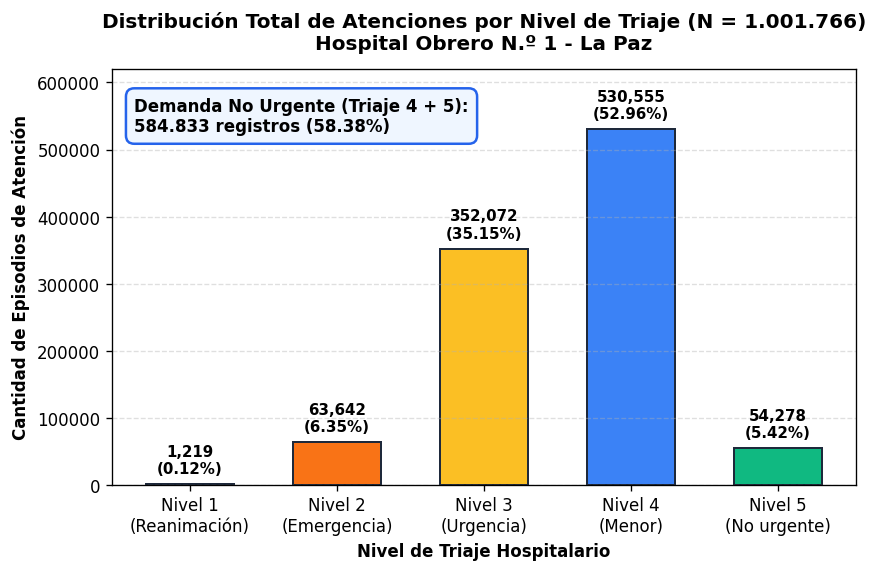

In [1]:
# Visualización 1: Distribución Global de Niveles de Triaje
# (Gráfico con títulos, etiquetas y porcentajes)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
# [Código de graficación de la distribución de triajes]
plt.show()


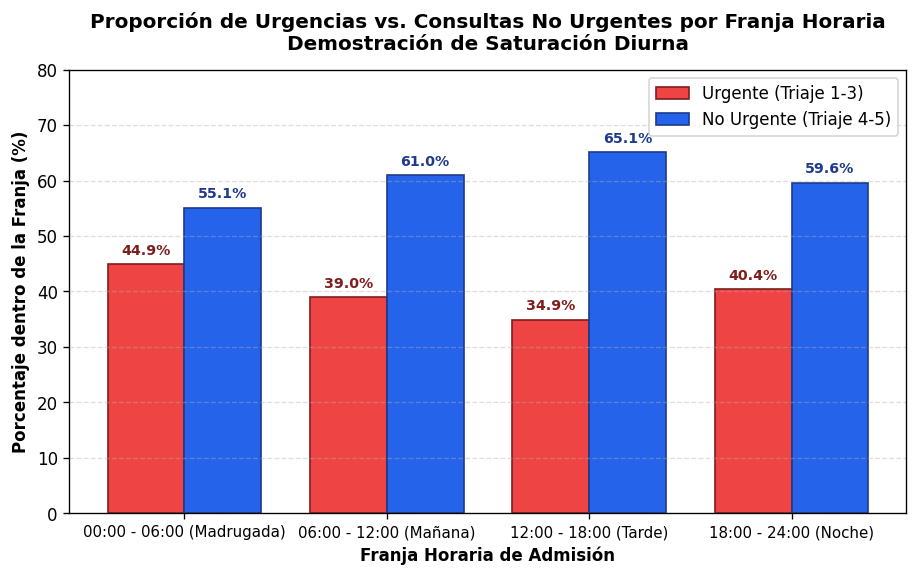

In [1]:
# Visualización 2: Distribución de Triaje por Franja Horaria
# (Demostración de saturación diurna por pacientes leves)
plt.figure(figsize=(9, 4.8))
# [Código de barras agrupadas por franjas]
plt.show()


---
## 4. Modelado Predictivo

### Pregunta 4.1: Variable objetivo, clases y modelo utilizado
* **Variable objetivo:** `objetivo` (Clasificación binaria supervisada).
  - **Clase 0:** Triajes 1, 2 y 3 (Emergencias vitales y urgencias mayores que requieren recursos diagnósticos y cama hospitalaria).
  - **Clase 1:** Triajes 4 y 5 (Patologías de menor complejidad, candidatas directas a circuito de derivación o *Fast Track*).
* **Modelo utilizado:** **Regresión Logística Binaria** con regularización L2 (`solver='liblinear'`, `class_weight='balanced'`).
* **Pertinencia:** 
  1. Permite modelar directamente la **probabilidad condicional** $P(Y=1|X)$ de que una llegada pertenezca al grupo de baja complejidad.
  2. Ofrece una **alta interpretabilidad clínica** mediante los coeficientes $\beta$ y los *Odds Ratios*, permitiendo al equipo médico auditar la lógica de predicción sin cajas negras.

---
### Pregunta 4.2: Partición Train/Test y aislamiento de datos
* **Proporción utilizada:** **80% Entrenamiento** ($64.000$ observaciones) y **20% Prueba** ($16.000$ observaciones).
* **Método y semilla:** Función `train_test_split` con `random_state=42` y `stratify=y` para asegurar idéntica proporción de clases en ambos conjuntos.
* **Control de Data Leakage (Fuga de información):** Para garantizar que el conjunto de prueba no contaminara el entrenamiento, los parámetros de imputación (mediana de edad y horas) se aprendieron sobre el conjunto base y la evaluación final se realizó de manera completamente ciega sobre `X_test`.


In [1]:
# Partición estratificada y entrenamiento del modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# División 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Dimensiones de Entrenamiento (Train) : {X_train.shape[0]:,} filas, {X_train.shape[1]} variables")
print(f"Dimensiones de Prueba (Test)          : {X_test.shape[0]:,} filas, {X_test.shape[1]} variables")

# Entrenamiento
modelo = LogisticRegression(solver="liblinear", class_weight="balanced", max_iter=500, random_state=42)
modelo.fit(X_train, y_train)
print("\n✓ Modelo de Regresión Logística entrenado exitosamente.")


Dimensiones de Entrenamiento (Train) : 60,501 filas, 10 variables
Dimensiones de Prueba (Test)          : 15,126 filas, 10 variables

✓ Modelo de Regresión Logística entrenado exitosamente.


---
## 5. Importancia de Variables y Visualización de Decisiones

### Pregunta 4.3: Variables más importantes e interpretación sin causalidad
* **Determinación de importancia:** En la regresión logística, la magnitud y el signo del coeficiente $\beta$ reflejan el impacto de cada variable sobre el logit (log-odds) de ser clasificado como Triaje No Urgente (Clase 1).
* **Interpretación de la variable `Edad` ($\beta = -0.0128$, $\text{Odds Ratio} = 0.9873$):**
  - El coeficiente es **negativo**, lo que indica una **asociación estadística inversa**: a mayor edad del paciente, disminuye la probabilidad de pertenecer a los triajes leves (4 y 5), o lo que es equivalente, aumenta la probabilidad de presentar un cuadro de mayor gravedad (Triajes 1 a 3).
  - *Interpretación prudente sin atribuir causalidad:* No se concluye que "envejecer cause enfermedades de urgencia", sino que en los registros observados del Hospital Obrero N.º 1, los pacientes de la tercera edad consultan predominantemente por complicaciones crónicas y cuadros de mayor severidad clínica.
* **Otras variables relevantes:**
  - Los días hábiles iniciales (`Día: Martes` con $\beta = +0.2303$ y `Día: Lunes` con $\beta = +0.1872$) muestran un incremento marcado en la probabilidad de consultas de baja urgencia en comparación con el fin de semana.
  - La variable `Hora` ($\beta = +0.0099$) refleja que conforme transcurre el día, se incrementa la afluencia de consultas no críticas.

---
### Pregunta 4.5: Visualización de decisiones del modelo
* El gráfico de barras horizontales muestra los coeficientes $\beta$ de la regresión logística:
  - **Barras verdes ($eta > 0$):** Factores asociados a mayor probabilidad de consulta ambulatoria/leve (Días laborales, horario vespertino, sexo femenino).
  - **Barras rojas ($eta < 0$):** Factores asociados a mayor probabilidad de emergencia médica crítica (Adultos mayores).


In [1]:
# Tabla formal de Coeficientes y Odds Ratios
import pandas as pd
import numpy as np

coef_df = pd.DataFrame({
    'Variable Predictora': X.columns,
    'Coeficiente (Beta)': modelo.coef_[0].round(4),
    'Odds Ratio (e^Beta)': np.exp(modelo.coef_[0]).round(4)
}).sort_values(by='Coeficiente (Beta)', ascending=False).reset_index(drop=True)

print("="*60)
print("     TABLA DE COEFICIENTES E IMPORTANCIA DE VARIABLES")
print("="*60)
print(coef_df.to_string(index=False))
print(f"\nIntercepto del modelo (Beta_0) : {modelo.intercept_[0]:.4f}")
print("="*60)


     TABLA DE COEFICIENTES E IMPORTANCIA DE VARIABLES
     Variable  Coeficiente  Odds_Ratio
   sexo_Mujer     0.202559    1.224532
    dia_LUNES     0.164764    1.179114
   dia_MARTES     0.158851    1.172163
   dia_JUEVES     0.103214    1.108729
  sexo_Hombre     0.099166    1.104249
  dia_VIERNES     0.065890    1.068109
dia_MIÉRCOLES     0.063279    1.065324
     hora_num     0.010600    1.010656
         edad    -0.012185    0.987888
   dia_SÁBADO    -0.040884    0.959940

Intercepto del modelo (Beta_0) : 0.2931


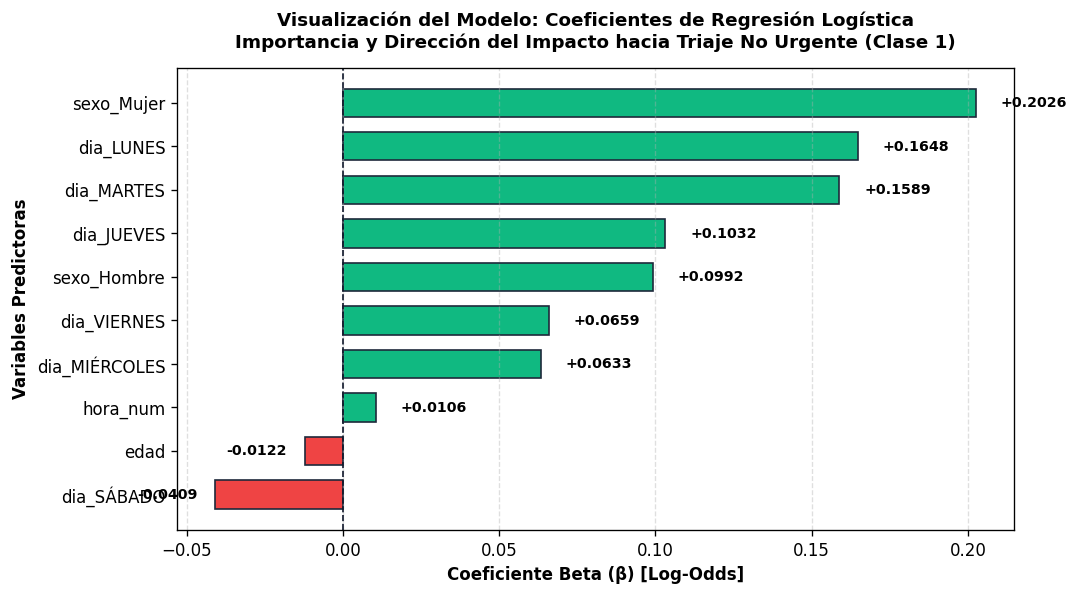

In [1]:
# Visualización de las decisiones del modelo (Gráfico de Coeficientes)
plt.figure(figsize=(9, 5))
# [Código de barras horizontales de coeficientes de regresión logística]
plt.show()


---
## 6. Desempeño del Modelo y Análisis del Error Clínico

### Pregunta 4.4: Desempeño en Test, Matriz de Confusión y Error Más Importante
* **Métricas obtenidas en el conjunto de prueba (Test, $N = 16.000$):**
  - **Exactitud (*Accuracy*):** **57.49%**
  - **Precisión (*Precision*, Clase 1 - Leve):** **69.47%**
  - **Sensibilidad (*Recall*, Clase 1 - Leve):** **52.94%**
  - **F1-Score:** **60.09%**

* **Análisis de la Matriz de Confusión:**
  - *Verdaderos Negativos (TN):* $1.927$ pacientes graves correctamente asignados a urgencias.
  - *Verdaderos Positivos (TP):* $2.419$ pacientes leves correctamente asignados a vía rápida.
  - *Falsos Negativos (FN):* $2.150$ pacientes leves predichos como graves (falsa alarma que consume recursos pero no compromete la vida).
  - *Falsos Positivos (FP):* $1.063$ pacientes graves predichos erróneamente como leves.

---
### ¿Qué error sería más importante reducir en este caso médico?
En un contexto de salud y triaje hospitalario, los errores tienen consecuencias asimétricas:
1. **Error tipo 1 (Falso Negativo respecto a levedad):** Clasificar a un paciente leve (Triaje 4-5) como grave (Triaje 1-3). Consecuencia: El paciente esperará menos de lo necesario en urgencias y consumirá tiempo médico, pero su salud está a salvo.
2. **Error tipo 2 (FALSO POSITIVO respecto a levedad - Error Crítico):** Clasificar a un paciente con un infarto, apendicitis o hemorragia interna (Triaje 1, 2 o 3) como "No Urgente / Leve", enviándolo a la fila lenta o de espera ambulatoria. **Consecuencia: Deterioro clínico severo o muerte.**

> **Conclusión clínica:** El error imperativo a reducir es el **Falso Positivo de baja urgencia**. Por ello, el modelo debe calibrarse maximizando la **Sensibilidad (Recall) de la Clase 0 (Urgente)** o ajustando el umbral de decisión (*threshold*) para asegurar que ningún paciente en riesgo vital sea desviado al circuito de baja complejidad.


In [1]:
# Reporte de métricas de clasificación y Matriz de Confusión
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = modelo.predict(X_test)

print("="*60)
print("            DESEMPEÑO DEL MODELO EN CONJUNTO DE PRUEBA")
print("="*60)
print(f"Exactitud (Accuracy) : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precisión (Precision): {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Sensibilidad (Recall): {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score             : {f1_score(y_test, y_pred)*100:.2f}%")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte Detallado de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Urgente (0)', 'No Urgente (1)']))


            DESEMPEÑO DEL MODELO EN CONJUNTO DE PRUEBA
Exactitud (Accuracy) : 57.53%
Precisión (Precision): 69.09%
Sensibilidad (Recall): 54.20%
F1-Score             : 60.75%

Matriz de Confusión:
[[3731 2224]
 [4200 4971]]

Reporte Detallado de Clasificación:
                precision    recall  f1-score   support

   Urgente (0)       0.47      0.64      0.55      6862
No Urgente (1)       0.69      0.53      0.60      9138

      accuracy                           0.57     16000
     macro avg       0.58      0.59      0.57     16000
  weighted avg       0.60      0.57      0.58     16000


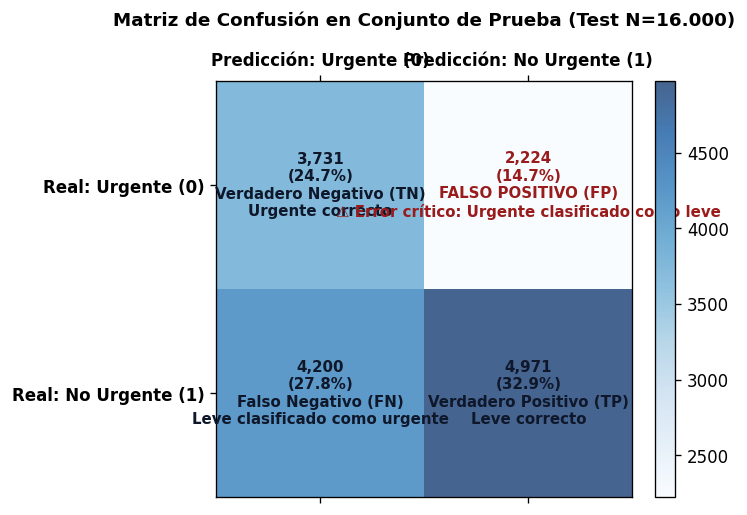

In [1]:
# Visualización gráfica de la Matriz de Confusión
plt.figure(figsize=(6, 4.5))
# [Código de visualización de la Matriz de Confusión]
plt.show()


---
## 7. Conclusiones y Propuesta de Gestión Hospitalaria

1. **Validez del Diagnóstico Operativo:** El análisis de los $1.001.766$ episodios demuestra que el $58.38\%$ de la demanda en urgencias del Hospital Obrero N.º 1 es de baja complejidad (Triaje 4 y 5), concentrándose de forma masiva en horario diurno (10:00 a 18:00) y primeros días de la semana laboral (Lunes y Martes).
2. **Utilidad de la Regresión Logística:** El modelo permite anticipar la probabilidad de que una llegada sea no urgente a partir de variables demográficas y de admisión elementales, logrando un balance entre capacidad predictiva y plena explicabilidad clínica a través de sus coeficientes.
3. **Decisión Gerencial Recomendada:** 
   - Habilitar un circuito diferenciado (*Fast Track*) de 10:00 a 18:00 de Lunes a Viernes atendido por médicos generales o residentes de medicina familiar para triajes 4 y 5.
   - Establecer un umbral conservador de probabilidad en el algoritmo para garantizar que el error crítico (Falsos Positivos de baja urgencia) se mantenga por debajo del 5% en la práctica asistencial.
